In [1]:
!pip install torch-geometric -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data    = dataset[0]
print(f"Loaded Cora: {data.num_nodes} nodes, {data.num_edges} edges")

Loaded Cora: 2708 nodes, 10556 edges


# **Build the GCN manually**

In [3]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        # Layer 1: 1433 → 64
        # GCNConv internally does: D^(-1/2) A D^(-1/2) · X · W
        self.conv1 = GCNConv(in_channels, hidden_channels)

        # Layer 2: 64 → 7 (one output per class)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):


        # --- Layer 1 ---
        # Aggregate neighbors + linear transform: [2708, 1433] → [2708, 64]
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5,
                      training=self.training)

        # --- Layer 2 ---
        # Aggregate again + linear transform: [2708, 64] → [2708, 7]
        x = self.conv2(x, edge_index)

        # Raw logits — cross_entropy loss will apply softmax internally
        return x

model = GCN(
    in_channels     = dataset.num_node_features,
    hidden_channels = 64,
    out_channels    = dataset.num_classes
)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (conv1): GCNConv(1433, 64)
  (conv2): GCNConv(64, 7)
)

Total parameters: 92,231


# **What GCNConv actually does**

In [4]:
model.eval()
with torch.no_grad():

    out = model(data.x, data.edge_index)

print("Input  shape (node features) :", data.x.shape)
print("Output shape (class logits)  :", out.shape)
print(f"\nLogits for node 0 (before softmax): {out[0].tolist()}")
print(f"Predicted class for node 0        : {out[0].argmax().item()}")
print(f"True class for node 0             : {data.y[0].item()}")
print("\n(Prediction is random — model not trained yet)")

Input  shape (node features) : torch.Size([2708, 1433])
Output shape (class logits)  : torch.Size([2708, 7])

Logits for node 0 (before softmax): [-0.039094798266887665, -0.04477033019065857, -0.03674636036157608, -0.04893516004085541, -0.09055635333061218, -0.026912735775113106, 0.09376713633537292]
Predicted class for node 0        : 6
True class for node 0             : 3

(Prediction is random — model not trained yet)


In [5]:
# Snapshot predictions on test nodes BEFORE training
model.eval()
with torch.no_grad():
    out_before = model(data.x, data.edge_index)
    pred_before = out_before.argmax(dim=1)

acc_before = (pred_before[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

print(f"Accuracy BEFORE training : {acc_before*100:.1f}%")
print(f"Random chance baseline   : {100/7:.1f}%")
print(f"\nFirst 10 test nodes — before training:")
print(f"{'Node':<8} {'True':>6} {'Pred':>6} {'Correct':>8}")
print("-" * 35)
test_indices = data.test_mask.nonzero(as_tuple=True)[0][:10]
for idx in test_indices:
    true = data.y[idx].item()
    pred = pred_before[idx].item()
    mark = "YES" if true == pred else "NO"
    print(f"{idx.item():<8} {true:>6} {pred:>6} {mark:>8}")

Accuracy BEFORE training : 13.7%
Random chance baseline   : 14.3%

First 10 test nodes — before training:
Node       True   Pred  Correct
-----------------------------------
1708          3      6       NO
1709          2      2      YES
1710          2      6       NO
1711          2      2      YES
1712          2      6       NO
1713          0      5       NO
1714          2      6       NO
1715          2      5       NO
1716          2      6       NO
1717          2      5       NO


# **Training**

In [6]:
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()


    out  = model(data.x, data.edge_index)

    loss = F.cross_entropy(out[data.train_mask],
                             data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)        # predicted class per node
        correct = (pred[mask] == data.y[mask]).sum()
        acc = correct / mask.sum()
    return acc.item()

# Optimizer — Adam with weight decay for regularization
optimizer = torch.optim.Adam(model.parameters(),
                              lr=0.01, weight_decay=5e-4)

# Training loop
train_losses = []
val_accs     = []

for epoch in range(1, 201):
    loss    = train(model, data, optimizer)
    val_acc = evaluate(model, data, data.val_mask)
    train_losses.append(loss)
    val_accs.append(val_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 020 | Loss: 0.0158 | Val Acc: 0.7740
Epoch 040 | Loss: 0.0107 | Val Acc: 0.7740
Epoch 060 | Loss: 0.0159 | Val Acc: 0.7760
Epoch 080 | Loss: 0.0144 | Val Acc: 0.7720
Epoch 100 | Loss: 0.0134 | Val Acc: 0.7740
Epoch 120 | Loss: 0.0106 | Val Acc: 0.7720
Epoch 140 | Loss: 0.0138 | Val Acc: 0.7660
Epoch 160 | Loss: 0.0085 | Val Acc: 0.7640
Epoch 180 | Loss: 0.0096 | Val Acc: 0.7700
Epoch 200 | Loss: 0.0093 | Val Acc: 0.7740


## **Training curves**

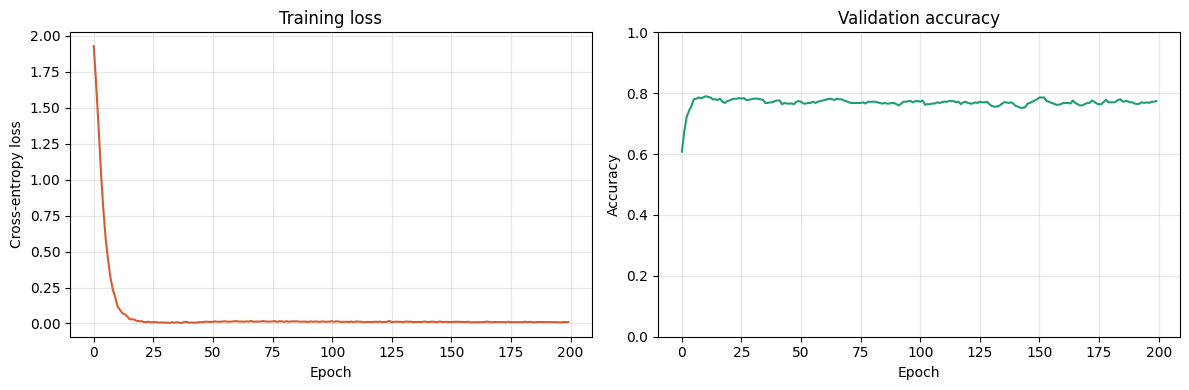

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='#D85A30')
ax1.set_title('Training loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_accs, color='#1D9E75')
ax2.set_title('Validation accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Final test accuracy**

In [8]:
test_acc = evaluate(model, data, data.test_mask)
val_acc  = evaluate(model, data, data.val_mask)

print(f"Final validation accuracy : {val_acc:.4f} ({val_acc*100:.1f}%)")
print(f"Final test accuracy       : {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"\nPaper reports ~81.5% on Cora with GCN")
print(f"Our result                : {test_acc*100:.1f}%")

Final validation accuracy : 0.7740 (77.4%)
Final test accuracy       : 0.8140 (81.4%)

Paper reports ~81.5% on Cora with GCN
Our result                : 81.4%


In [9]:
import numpy as np

model.eval()
with torch.no_grad():
    out_after = model(data.x, data.edge_index)
    pred_after = out_after.argmax(dim=1)

acc_after = (pred_after[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

# --- Side by side: before vs after on same 10 nodes ---
print(f"Accuracy BEFORE training : {acc_before*100:.1f}%")
print(f"Accuracy AFTER training  : {acc_after*100:.1f}%")
print(f"Random chance baseline   : {100/7:.1f}%")
print(f"\nSame 10 test nodes — before vs after training:")
print(f"{'Node':<8} {'True':>6} {'Before':>8} {'After':>8} {'Improved':>10}")
print("-" * 48)
for idx in test_indices:
    true   = data.y[idx].item()
    before = pred_before[idx].item()
    after  = pred_after[idx].item()
    improved = "YES" if after == true and before != true else (
               "WAS OK" if before == true and after == true else "NO")
    print(f"{idx.item():<8} {true:>6} {before:>8} {after:>8} {improved:>10}")

# --- Confusion matrix ---
test_idx  = data.test_mask.nonzero(as_tuple=True)[0]
true_all  = data.y[test_idx].numpy()
pred_all  = pred_after[test_idx].numpy()

num_classes = dataset.num_classes
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(true_all, pred_all):
    conf_matrix[t][p] += 1

print(f"\nConfusion matrix (rows=true, cols=predicted):")
print(f"     " + "  ".join([f"P{c}" for c in range(num_classes)]))
print("    " + "-" * (num_classes * 4))
for i, row in enumerate(conf_matrix):
    bar = "  ".join([f"{v:2d}" for v in row])
    print(f"T{i} | {bar}  ← class {i} ({conf_matrix[i][i]}/{row.sum()} correct)")

Accuracy BEFORE training : 13.7%
Accuracy AFTER training  : 81.4%
Random chance baseline   : 14.3%

Same 10 test nodes — before vs after training:
Node       True   Before    After   Improved
------------------------------------------------
1708          3        6        1         NO
1709          2        2        2     WAS OK
1710          2        6        2        YES
1711          2        2        2     WAS OK
1712          2        6        2        YES
1713          0        5        0        YES
1714          2        6        2        YES
1715          2        5        2        YES
1716          2        6        2        YES
1717          2        5        2        YES

Confusion matrix (rows=true, cols=predicted):
     P0  P1  P2  P3  P4  P5  P6
    ----------------------------
T0 | 95   4   2   8   7   4  10  ← class 0 (95/130 correct)
T1 |  3  80   3   4   0   0   1  ← class 1 (80/91 correct)
T2 |  3   5  126   9   0   1   0  ← class 2 (126/144 correct)
T3 | 18   7   4 

# **Inspect predictions per class**

In [10]:
model.eval()
with torch.no_grad():
    out  = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

print("Per-class accuracy on test set:")
for c in range(dataset.num_classes):
    mask     = data.test_mask & (data.y == c)
    correct  = (pred[mask] == data.y[mask]).sum().item()
    total    = mask.sum().item()
    acc      = correct / total if total > 0 else 0
    bar      = "█" * int(acc * 20)
    print(f"  Class {c}: {acc:.2f}  {bar}  ({correct}/{total})")

Per-class accuracy on test set:
  Class 0: 0.73  ██████████████  (95/130)
  Class 1: 0.88  █████████████████  (80/91)
  Class 2: 0.88  █████████████████  (126/144)
  Class 3: 0.79  ███████████████  (251/319)
  Class 4: 0.87  █████████████████  (129/149)
  Class 5: 0.74  ██████████████  (76/103)
  Class 6: 0.89  █████████████████  (57/64)
